In [1]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정 + 실험 데이터 로드
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import (proportions_ztest, proportion_effectsize,
                                          confint_proportions_2indep, proportion_confint)
from statsmodels.stats.power import NormalIndPower
plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다. (정답을 심고 확인하는 모든 시뮬레이션에 적용)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    # 리눅스·Colab에서 한글이 □□로 보이면 아래를 먼저 실행하세요.
    # !apt-get -qq install -y fonts-nanum && rm -rf ~/.cache/matplotlib
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# ── 실제 무작위 실험 데이터 (라이브러리 제공) ──
resume = sm.datasets.get_rdataset("ResumeNames", "AER").data     # 이력서 현장실험 4,870건
star   = sm.datasets.get_rdataset("Star", "Ecdat").data          # Project STAR (연속형 결과 RCT)

print("준비 완료!")
print("numpy       :", np.__version__)
print("statsmodels :", sm.__version__)
print()
print(f"resume : {resume.shape}  — 무작위 배정 요인 2개(ethnicity, quality), 결과 = call")
print(f"star   : {star.shape}  — 무작위 배정된 학급 유형 3종, 결과 = 시험 점수")
print()
print("이력서 실험 요약 (그룹별 연락률):")
print(pd.crosstab(resume["ethnicity"], resume["call"], normalize="index").round(4))  # 분할표(교차표) — 두 범주의 조합별 개수를 셈

준비 완료!
numpy       : 2.4.6
statsmodels : 0.14.6

resume : (4870, 27)  — 무작위 배정 요인 2개(ethnicity, quality), 결과 = call
star   : (5748, 8)  — 무작위 배정된 학급 유형 3종, 결과 = 시험 점수

이력서 실험 요약 (그룹별 연락률):
call           no     yes
ethnicity                
afam       0.9355  0.0645
cauc       0.9035  0.0965


In [2]:
# [C2] 잠재결과 시뮬레이션 — '신의 시점'에서 Y(1)과 Y(0)을 모두 본다 (현실엔 불가능)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 2000
Y0 = np.random.normal(100, 20, n)                  # 처치 안 받았을 때의 구매액
true_tau = 8.0                                     # 우리가 '심은' 진짜 효과 (+8)
Y1 = Y0 + true_tau + np.random.normal(0, 5, n)     # 처치 받았을 때 (효과 + 개인차)

sim = pd.DataFrame({"Y0": Y0, "Y1": Y1})
sim["tau_i"] = sim["Y1"] - sim["Y0"]               # 개인 효과 (현실엔 못 봄)
print(sim.head().round(1))
print(f"\n[신의 시점] 진짜 ATE = E[Y(1) - Y(0)] = {sim['tau_i'].mean():.2f}  (우리가 심은 값 ≈ {true_tau})")
print("→ 현실에서는 한 사람당 Y0, Y1 중 하나만 보입니다. 이 표는 시뮬레이션이라 둘 다 보이는 것뿐이에요.")

      Y0     Y1  tau_i
0  109.9  114.6    4.6
1   97.2  104.5    7.3
2  113.0  117.0    4.0
3  130.5  136.9    6.5
4   95.3   93.8   -1.5

[신의 시점] 진짜 ATE = E[Y(1) - Y(0)] = 7.97  (우리가 심은 값 ≈ 8.0)
→ 현실에서는 한 사람당 Y0, Y1 중 하나만 보입니다. 이 표는 시뮬레이션이라 둘 다 보이는 것뿐이에요.


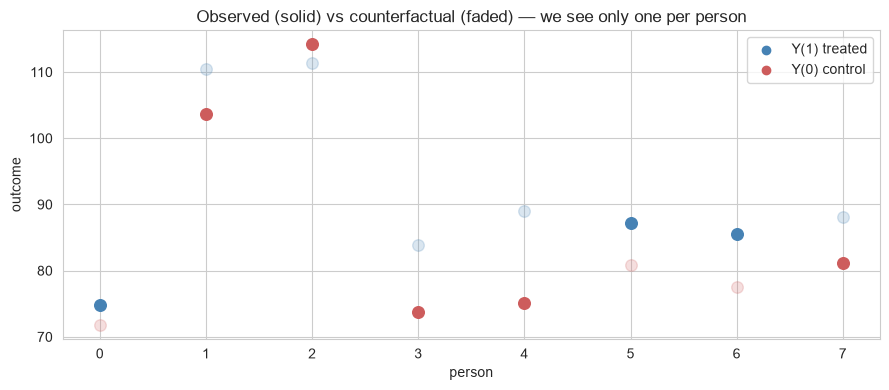

In [3]:
# [C3] 근본 문제를 그림으로 — 관측되는 값과 가려지는 반사실
np.random.seed(1)                                                 # 재현성: 난수를 항상 같게 고정
idx = np.random.choice(n, 8, replace=False)
T_demo = np.random.binomial(1, 0.5, 8)             # 무작위로 처치/대조 배정
fig, ax = plt.subplots(figsize=(9, 4))                            # 그래프 하나를 그릴 도화지 준비
for k, i in enumerate(idx):
    obs = "Y1" if T_demo[k] == 1 else "Y0"
    ax.scatter(k, Y1[i], color="steelblue", s=70, alpha=1 if obs == "Y1" else 0.2)
    ax.scatter(k, Y0[i], color="indianred", s=70, alpha=1 if obs == "Y0" else 0.2)
ax.scatter([], [], color="steelblue", label="Y(1) treated")
ax.scatter([], [], color="indianred", label="Y(0) control")
ax.set_xlabel("person"); ax.set_ylabel("outcome")
ax.set_title("Observed (solid) vs counterfactual (faded) — we see only one per person")
ax.legend(); plt.tight_layout(); plt.show()                       # 그래프 간격 자동 정리 후 출력

In [4]:
# [C4] 무작위 하에서 '대조군 평균'이 처치군의 반사실을 메운다
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 4000
Y0 = np.random.normal(100, 20, n)
Y1 = Y0 + 8 + np.random.normal(0, 5, n)        # 진짜 효과 +8
T = np.random.binomial(1, 0.5, n)              # 무작위 배정
Y = np.where(T == 1, Y1, Y0)                   # 현실에서 관측되는 값

# '신의 시점': 처치군이 안 받았더라면의 진짜 평균
counterfactual_treated = Y0[T == 1].mean()
control_mean = Y[T == 0].mean()                # 우리가 실제로 쓰는 대용물
print(f"처치군의 반사실 E[Y(0)|T=1] (신의 시점) = {counterfactual_treated:.2f}")
print(f"대조군 평균 (현실에서 쓰는 추정치)        = {control_mean:.2f}")
print(f"→ 거의 같습니다! 무작위라 대조군이 처치군의 '안 받았더라면'을 대신합니다.")
print(f"\nATE 추정 = {Y[T==1].mean() - control_mean:.2f}  (진짜 효과 8에 근접)")

처치군의 반사실 E[Y(0)|T=1] (신의 시점) = 100.48
대조군 평균 (현실에서 쓰는 추정치)        = 100.29
→ 거의 같습니다! 무작위라 대조군이 처치군의 '안 받았더라면'을 대신합니다.

ATE 추정 = 8.07  (진짜 효과 8에 근접)


In [6]:
# [C2] 잠재결과 시뮬레이션 — '신의 시점'에서 Y(1)과 Y(0)을 모두 본다 (현실엔 불가능)
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 2000
Y0 = np.random.normal(100, 20, n)                  # 처치 안 받았을 때의 구매액
true_tau = 0                                     # 우리가 '심은' 진짜 효과 (+8)
Y1 = Y0 + true_tau + np.random.normal(0, 5, n)     # 처치 받았을 때 (효과 + 개인차)

sim = pd.DataFrame({"Y0": Y0, "Y1": Y1})
sim["tau_i"] = sim["Y1"] - sim["Y0"]               # 개인 효과 (현실엔 못 봄)
print(sim.head().round(1))
print(f"\n[신의 시점] 진짜 ATE = E[Y(1) - Y(0)] = {sim['tau_i'].mean():.2f}  (우리가 심은 값 ≈ {true_tau})")
print("→ 현실에서는 한 사람당 Y0, Y1 중 하나만 보입니다. 이 표는 시뮬레이션이라 둘 다 보이는 것뿐이에요.")

      Y0     Y1  tau_i
0  109.9  106.6   -3.4
1   97.2   96.5   -0.7
2  113.0  109.0   -4.0
3  130.5  128.9   -1.5
4   95.3   85.8   -9.5

[신의 시점] 진짜 ATE = E[Y(1) - Y(0)] = -0.03  (우리가 심은 값 ≈ 0)
→ 현실에서는 한 사람당 Y0, Y1 중 하나만 보입니다. 이 표는 시뮬레이션이라 둘 다 보이는 것뿐이에요.


true tau에 0을 넣어도 추정치가 0일뿐 진짜 0은 아니다
- 그걸 판단하기 위해 t 검정, p값 등을 사용
효과가 없다
- ATE = 0은 두 집단 개인들이 똑같다는게 아니라 
평균적으로 상쇄된다 = 어떤사람은 처치를 통해 도움을 받고 어떤 사람은 처치를 통해 오히려 손해를 보았다 -> 저 둘이 상쇄되어 ATE가 0이 나왔다 
**처치효과의 이질성**
- 서브그룹 분석(subgroup analysis), 조건부 평균처치효과(CATE, Conditional ATE), 상호작용항을 넣은 회귀분석 등을 통해 누구에게 효과가 있고 누구에게 효과가 없는지 본다


In [7]:
# [C6] 편향 시뮬레이션 — '스스로 선택'이 만든 가짜 효과 vs 무작위가 준 진짜 효과
np.random.seed(42)                                                # 재현성: 난수를 항상 같게 고정
n = 4000
X = np.random.normal(0, 1, n)                       # 숨은 교란 (예: 서비스 애착도)
true_effect = 5.0                                   # 우리가 심은 진짜 처치효과

# (A) 관찰 데이터: 애착(X) 높은 사람이 처치(프리미엄)를 더 선택
p_self = 1 / (1 + np.exp(-2 * X))
T_obs = np.random.binomial(1, p_self)                             # 이항 난수 — n번 시도 중 성공 횟수
Y_obs = 50 + true_effect * T_obs + 12 * X + np.random.normal(0, 5, n)   # X도 결과를 끌어올림
naive = Y_obs[T_obs == 1].mean() - Y_obs[T_obs == 0].mean()

# (B) 무작위 실험: 동전 던지듯 배정 (X와 무관)
T_rand = np.random.binomial(1, 0.5, n)                            # 이항 난수 — n번 시도 중 성공 횟수
Y_rand = 50 + true_effect * T_rand + 12 * X + np.random.normal(0, 5, n)
rand = Y_rand[T_rand == 1].mean() - Y_rand[T_rand == 0].mean()

print(f"진짜 효과(심음)            : {true_effect:.1f}")
print(f"(A) 관찰 데이터 단순 비교  : {naive:5.1f}   ← 편향! (교란 X가 부풀림)")
print(f"(B) 무작위 실험 단순 비교  : {rand:5.1f}   ← 진짜 효과에 근접")

진짜 효과(심음)            : 5.0
(A) 관찰 데이터 단순 비교  :  19.8   ← 편향! (교란 X가 부풀림)
(B) 무작위 실험 단순 비교  :   4.8   ← 진짜 효과에 근접


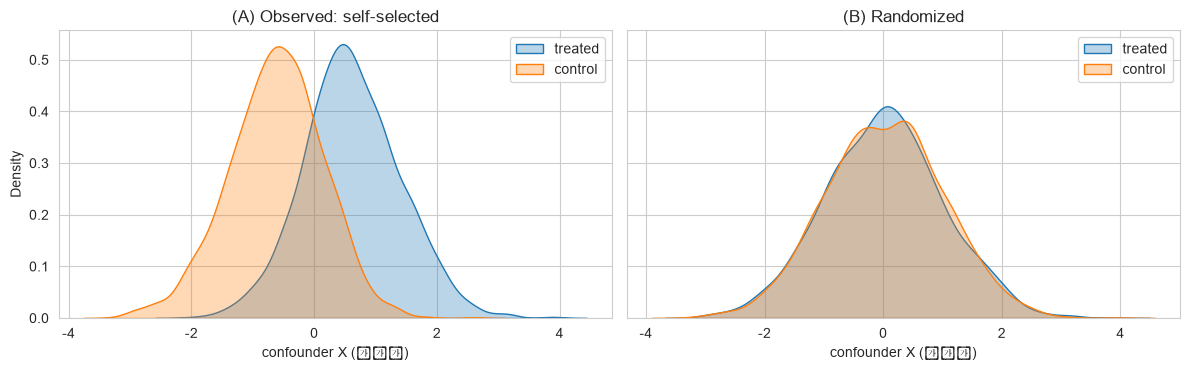

In [8]:
# [C7] 왜 무작위가 통할까 — 배정별로 교란 X의 분포를 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)    # 그림 한 장에 그래프 2개(1행 2열)
for ax, T, title in [(axes[0], T_obs, "(A) Observed: self-selected"),
                     (axes[1], T_rand, "(B) Randomized")]:
    sns.kdeplot(X[T == 1], ax=ax, label="treated", fill=True, alpha=0.3)  # 매끄러운 밀도 곡선
    sns.kdeplot(X[T == 0], ax=ax, label="control", fill=True, alpha=0.3)  # 매끄러운 밀도 곡선
    ax.set_title(title); ax.set_xlabel("confounder X (애착도)"); ax.legend()
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력

In [9]:
# [C8] 검정력 분석 — 전환율 10% → 12%(=+2%p)를 80% 검정력으로 잡으려면?
base, target = 0.10, 0.12
es = proportion_effectsize(target, base)        # 두 비율의 효과 크기
n_per_group = NormalIndPower().solve_power(effect_size=es, alpha=0.05, power=0.8, alternative="two-sided")  # α·검정력·효과 크기 → 필요한 표본 수를 역산
print(f"효과 크기(h) = {es:.4f}")
print(f"필요한 표본 = 그룹당 약 {np.ceil(n_per_group):,.0f}명  (총 {np.ceil(n_per_group)*2:,.0f}명)")

# 잡고 싶은 향상폭이 작아질수록 표본이 폭증한다
print("\n[향상폭별 그룹당 필요 표본]")
for tgt in [0.105, 0.11, 0.12, 0.14]:
    e = proportion_effectsize(tgt, base)                          # 두 비율을 표준화된 효과 크기 h로 변환
    nn = NormalIndPower().solve_power(effect_size=e, alpha=0.05, power=0.8)  # α·검정력·효과 크기 → 필요한 표본 수를 역산
    print(f"  10% → {tgt*100:.1f}%  (+{(tgt-base)*100:.1f}%p) : 약 {np.ceil(nn):>8,.0f}명")

효과 크기(h) = 0.0640
필요한 표본 = 그룹당 약 3,835명  (총 7,670명)

[향상폭별 그룹당 필요 표본]
  10% → 10.5%  (+0.5%p) : 약   57,756명
  10% → 11.0%  (+1.0%p) : 약   14,745명
  10% → 12.0%  (+2.0%p) : 약    3,835명
  10% → 14.0%  (+4.0%p) : 약    1,030명


In [10]:
# [C9] SRM 점검 — 배정이 의도(50:50)대로 됐나? (카이제곱 적합도)
n_a, n_b = 9980, 10020          # 실제 배정된 두 그룹 크기 (정상 예시)
total = n_a + n_b
chi2_srm, p_srm = stats.chisquare([n_a, n_b], [total/2, total/2])  # 카이제곱 적합도 검정 — 관측이 기대 비율과 맞나
print(f"그룹 크기: A={n_a}, B={n_b}")
print(f"SRM 검정: chi2 = {chi2_srm:.2f}, p = {p_srm:.3f}")
print("→", "정상 (p가 크면 50:50과 유의차 없음)" if p_srm > 0.01 else "⚠️ SRM 의심! 배정/로깅 점검 필요")

# 만약 7000:13000처럼 치우쳤다면?
bad = stats.chisquare([7000, 13000], [10000, 10000])              # 카이제곱 적합도 검정 — 관측이 기대 비율과 맞나
print(f"\n[치우친 예 7000:13000] p = {bad.pvalue:.2e} → ⚠️ 심각한 SRM, 결과 분석 보류")

그룹 크기: A=9980, B=10020
SRM 검정: chi2 = 0.08, p = 0.777
→ 정상 (p가 크면 50:50과 유의차 없음)

[치우친 예 7000:13000] p = 0.00e+00 → ⚠️ 심각한 SRM, 결과 분석 보류


In [11]:
# [C10] peeking 시뮬 — 진짜 효과가 '0'인데도, 매일 들여다보면 거짓 양성이 폭증
np.random.seed(3)                                                 # 재현성: 난수를 항상 같게 고정
runs = 1500
fp_peek = 0      # 중간에 한 번이라도 유의하면 '유의'로 카운트
fp_once = 0      # 끝에 딱 한 번만 검정
for _ in range(runs):
    cA = cB = nA = nB = 0
    hit = False
    for step in range(10):                      # 10번 들여다봄
        cA += np.random.binomial(400, 0.10); nA += 400            # 이항 난수 — n번 시도 중 성공 횟수
        cB += np.random.binomial(400, 0.10); nB += 400      # A=B, 진짜 효과 0
        if proportions_ztest([cB, cA], [nB, nA])[1] < 0.05:       # 두 비율 z-검정 — 비율 차이를 표준오차로 나눔
            hit = True
    if hit: fp_peek += 1
    if proportions_ztest([cB, cA], [nB, nA])[1] < 0.05: fp_once += 1  # 두 비율 z-검정 — 비율 차이를 표준오차로 나눔
print(f"진짜 효과 = 0 인데도...")
print(f"  끝에 한 번만 검정: 거짓 양성률 = {fp_once/runs:.1%}   (의도한 5% 근처 ✓)")
print(f"  10번 훔쳐보기    : 거짓 양성률 = {fp_peek/runs:.1%}   (5%를 훨씬 초과! ✗)")

진짜 효과 = 0 인데도...
  끝에 한 번만 검정: 거짓 양성률 = 5.6%   (의도한 5% 근처 ✓)
  10번 훔쳐보기    : 거짓 양성률 = 18.9%   (5%를 훨씬 초과! ✗)


In [12]:
# [C8] 검정력 분석 — 전환율 10% → 12%(=+2%p)를 80% 검정력으로 잡으려면?
base, target = 0.05, 0.06
es = proportion_effectsize(target, base)        # 두 비율의 효과 크기
n_per_group = NormalIndPower().solve_power(effect_size=es, alpha=0.05, power=0.8, alternative="two-sided")  # α·검정력·효과 크기 → 필요한 표본 수를 역산
print(f"효과 크기(h) = {es:.4f}")
print(f"필요한 표본 = 그룹당 약 {np.ceil(n_per_group):,.0f}명  (총 {np.ceil(n_per_group)*2:,.0f}명)")

# 잡고 싶은 향상폭이 작아질수록 표본이 폭증한다
print("\n[향상폭별 그룹당 필요 표본]")
for tgt in [0.055, 0.06, 0.065, 0.07]:
    e = proportion_effectsize(tgt, base)                          # 두 비율을 표준화된 효과 크기 h로 변환
    nn = NormalIndPower().solve_power(effect_size=e, alpha=0.05, power=0.8)  # α·검정력·효과 크기 → 필요한 표본 수를 역산
    print(f"  5% → {tgt*100:.1f}%  (+{(tgt-base)*100:.1f}%p) : 약 {np.ceil(nn):>8,.0f}명")

효과 크기(h) = 0.0439
필요한 표본 = 그룹당 약 8,143명  (총 16,286명)

[향상폭별 그룹당 필요 표본]
  5% → 5.5%  (+0.5%p) : 약   31,218명
  5% → 6.0%  (+1.0%p) : 약    8,143명
  5% → 6.5%  (+1.5%p) : 약    3,766명
  5% → 7.0%  (+2.0%p) : 약    2,199명


In [13]:
# [C12] 실험 결과 집계 — 실제 무작위 배정 현장실험(ResumeNames)
# 그룹 A = afam형 이름, 그룹 B = cauc형 이름 (이름은 무작위 배정됨)
grp_A, grp_B = "afam", "cauc"
n_A = int((resume["ethnicity"] == grp_A).sum())
n_B = int((resume["ethnicity"] == grp_B).sum())
conv_A = int(((resume["ethnicity"] == grp_A) & (resume["call"] == "yes")).sum())
conv_B = int(((resume["ethnicity"] == grp_B) & (resume["call"] == "yes")).sum())
rate_A, rate_B = conv_A / n_A, conv_B / n_B

print(f"A({grp_A}형 이름): {conv_A}/{n_A} = {rate_A:.3%}")
print(f"B({grp_B}형 이름): {conv_B}/{n_B} = {rate_B:.3%}")
print(f"관측된 연락률 차이: {(rate_B - rate_A)*100:+.2f}%p")

# 실험 위생 점검 — 배정 비율이 의도대로였나(SRM)
_, p_srm0 = stats.chisquare([n_A, n_B], [(n_A + n_B) / 2] * 2)    # 카이제곱 적합도 검정 — 관측이 기대 비율과 맞나
print(f"\n[배정 점검] A:B = {n_A}:{n_B},  SRM 검정 p = {p_srm0:.3f}"
      f" → {'정상 (50:50과 유의차 없음)' if p_srm0 > 0.01 else '⚠️ SRM 의심'}")

A(afam형 이름): 157/2435 = 6.448%
B(cauc형 이름): 235/2435 = 9.651%
관측된 연락률 차이: +3.20%p

[배정 점검] A:B = 2435:2435,  SRM 검정 p = 1.000 → 정상 (50:50과 유의차 없음)


In [14]:
# [C13] 빈도주의 검정 — 두 비율 z-검정 + 차이의 95% 신뢰구간
z, p = proportions_ztest([conv_B, conv_A], [n_B, n_A])     # B-A 순서
ci_low, ci_high = confint_proportions_2indep(conv_B, n_B, conv_A, n_A, method="wald")  # 두 비율 '차이'의 신뢰구간 (0을 포함하면 비유의)
print(f"비율 z-검정 : z = {z:.3f}, p = {p:.4f}")
print(f"전환율 차이 (B - A) 95% CI : [{ci_low*100:+.2f}%p, {ci_high*100:+.2f}%p]")
print()
if p < 0.05:
    print("→ p < 0.05: '차이가 없다'를 기각. B의 전환율이 통계적으로 더 높다고 판단.")
else:
    print("→ p >= 0.05: 차이가 유의하지 않음(우연 배제 못 함).")

비율 z-검정 : z = 4.108, p = 0.0000
전환율 차이 (B - A) 95% CI : [+1.68%p, +4.73%p]

→ p < 0.05: '차이가 없다'를 기각. B의 전환율이 통계적으로 더 높다고 판단.


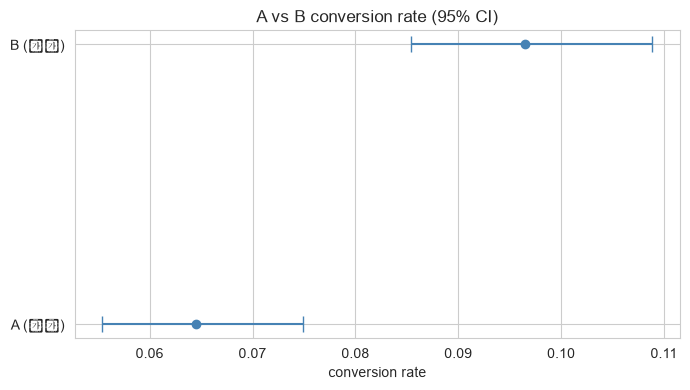

In [15]:
# [C14] [도식] 두 전환율과 95% 신뢰구간 비교
from statsmodels.stats.proportion import proportion_confint
ci_A = proportion_confint(conv_A, n_A, method="wilson")           # 한 비율의 신뢰구간 (Wilson 방법이 소표본에 안전)
ci_B = proportion_confint(conv_B, n_B, method="wilson")           # 한 비율의 신뢰구간 (Wilson 방법이 소표본에 안전)
fig, ax = plt.subplots(figsize=(7, 4))                            # 그래프 하나를 그릴 도화지 준비
ax.errorbar([rate_A, rate_B], [0, 1],                             # 오차막대(신뢰구간) 표시
            xerr=[[rate_A-ci_A[0], rate_B-ci_B[0]], [ci_A[1]-rate_A, ci_B[1]-rate_B]],
            fmt="o", capsize=6, color="steelblue")
ax.set_yticks([0, 1]); ax.set_yticklabels(["A (기존)", "B (신규)"])
ax.set_xlabel("conversion rate"); ax.set_title("A vs B conversion rate (95% CI)")
plt.tight_layout(); plt.show()                                    # 그래프 간격 자동 정리 후 출력